In [1]:
from google.colab import files
uploaded = files.upload()

Saving student-mat.csv to student-mat.csv


Loaded dataset shape: (395, 33)
Columns: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

=== Brief EDA ===
            count       mean       std   min   25%   50%   75%   max
school        395        NaN       NaN   NaN   NaN   NaN   NaN   NaN
sex           395        NaN       NaN   NaN   NaN   NaN   NaN   NaN
age         395.0  16.696203  1.276043  15.0  16.0  17.0  18.0  22.0
address       395        NaN       NaN   NaN   NaN   NaN   NaN   NaN
famsize       395        NaN       NaN   NaN   NaN   NaN   NaN   NaN
Pstatus       395        NaN       NaN   NaN   NaN   NaN   NaN   NaN
Medu        395.0   2.749367  1.094735   0.0   2.0   3.0   4.0   4.0
Fedu        395.0   2.521519  1.088201   0.0   2.0   2.0   3

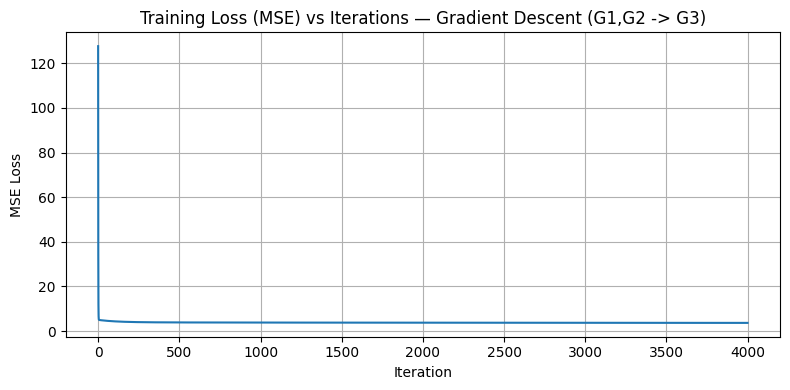

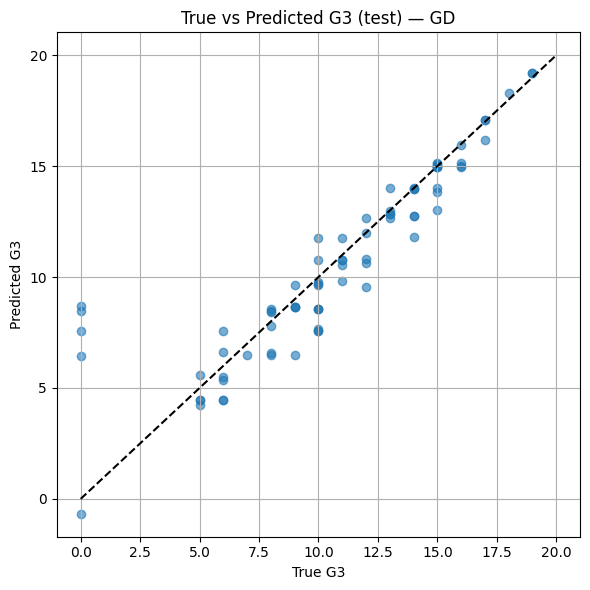


Other-feature matrix shape after encoding: (395, 39)
Iter 0, loss=127.629747
Iter 800, loss=17.120407
Iter 1600, loss=16.317606
Iter 2400, loss=15.978817
Iter 3200, loss=15.788517

--- Bonus results (excluding G1,G2) ---
Closed-form RMSE train: 3.8651, test: 4.1957
GD RMSE train: 3.9581, test: 4.2680


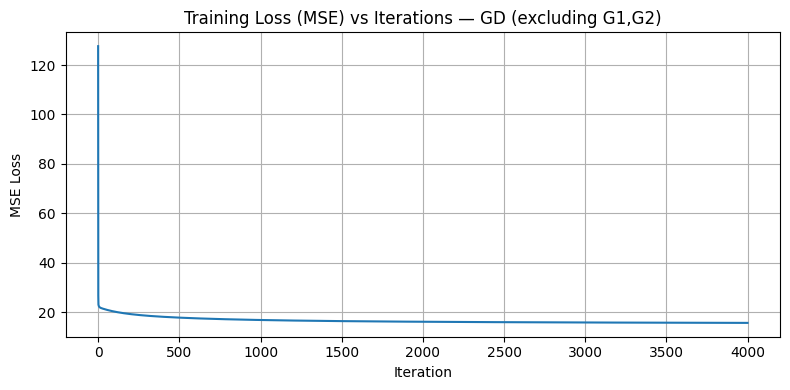


Saved plots: loss_g1g2.png, true_vs_pred_g1g2.png, loss_excluding_g1g2.png
Saved test predictions sample: predictions_g1g2_test_sample.csv


In [2]:
# Linear regression from scratch — Student Performance (UCI)
# Usage:
#  - Place student-mat.csv or student-por.csv in same folder and set DATA_FILE variable below.
#  - Run in Jupyter or python environment with numpy, pandas, matplotlib, sklearn (for split convenience).
#
# This implements:
#  - EDA summary
#  - Linear regression (closed-form normal equation with tiny ridge reg)
#  - Gradient descent (batch) from scratch with MSE loss + training loss plot
#  - RMSE on train and test
#  - Bonus: run model excluding G1,G2 (use other features)
#  - Saves plots to png files

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import os

# ---------- User config ----------
DATA_FILE = 'student-mat.csv'   # change to 'student-por.csv' if desired
SEP = ';'                      # UCI student files use semicolon
RANDOM_STATE = 42
TEST_SIZE = 0.2
# Gradient descent hyperparameters
LR = 0.001
N_ITERS = 4000
# ---------------------------------

# ---------- Utility functions ----------
def add_bias(X):
    return np.hstack([np.ones((X.shape[0],1)), X])

def predict(X, w):
    return X.dot(w)

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))

def closed_form_solution(X, y, reg=1e-8):
    XtX = X.T.dot(X)
    w = np.linalg.inv(XtX + reg*np.eye(XtX.shape[0])).dot(X.T).dot(y)
    return w

def gradient_descent(X, y, lr=1e-3, n_iters=1000, verbose=False):
    n, d = X.shape
    w = np.zeros(d)
    losses = []
    for it in range(n_iters):
        y_pred = X.dot(w)
        loss = mse(y, y_pred)
        losses.append(loss)
        grad = (-2/n) * X.T.dot(y - y_pred)
        w = w - lr * grad
        if verbose and (it % max(1, n_iters//5) == 0):
            print(f"Iter {it}, loss={loss:.6f}")
    return w, np.array(losses)

# ---------- Load dataset ----------
if not os.path.exists(DATA_FILE):
    raise FileNotFoundError(f"{DATA_FILE} not found. Download student-mat.csv or student-por.csv from UCI and place here.")

df = pd.read_csv(DATA_FILE, sep=SEP)
print("Loaded dataset shape:", df.shape)
print("Columns:", list(df.columns))

# ---------- EDA (brief) ----------
print("\n=== Brief EDA ===")
print(df.describe(include='all').T[['count','mean','std','min','25%','50%','75%','max']].head(20))
print("\nValue counts for categorical columns (sample):")
for col in df.select_dtypes(include=['object']).columns:
    print(f"\n{col} value counts:")
    print(df[col].value_counts(dropna=False).to_dict())

# ---------- Subtask A: Predict G3 using G1, G2 only ----------
X = df[['G1','G2']].values.astype(float)
y = df['G3'].values.astype(float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

X_train_b = add_bias(X_train)
X_test_b = add_bias(X_test)

# Closed-form
w_cf = closed_form_solution(X_train_b, y_train, reg=1e-8)
y_train_pred_cf = predict(X_train_b, w_cf)
y_test_pred_cf = predict(X_test_b, w_cf)
train_rmse_cf = rmse(y_train, y_train_pred_cf)
test_rmse_cf = rmse(y_test, y_test_pred_cf)

# Gradient descent
w_gd, losses = gradient_descent(X_train_b, y_train, lr=LR, n_iters=N_ITERS, verbose=True)
y_train_pred_gd = predict(X_train_b, w_gd)
y_test_pred_gd = predict(X_test_b, w_gd)
train_rmse_gd = rmse(y_train, y_train_pred_gd)
test_rmse_gd = rmse(y_test, y_test_pred_gd)

print("\n--- Subtask A results (G1,G2 -> G3) ---")
print("Closed-form weights:", w_cf)
print(f"Closed-form RMSE train: {train_rmse_cf:.4f}, test: {test_rmse_cf:.4f}")
print("GD weights:", w_gd)
print(f"GD RMSE train: {train_rmse_gd:.4f}, test: {test_rmse_gd:.4f}")

# Plot training loss vs iterations
plt.figure(figsize=(8,4))
plt.plot(np.arange(len(losses)), losses)
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.title("Training Loss (MSE) vs Iterations — Gradient Descent (G1,G2 -> G3)")
plt.grid(True)
plt.tight_layout()
plt.savefig("loss_g1g2.png", dpi=150)
plt.show()

# Optional: scatter true vs predicted on test
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred_gd, alpha=0.6)
plt.plot([0,20],[0,20],'k--')
plt.xlabel("True G3")
plt.ylabel("Predicted G3")
plt.title("True vs Predicted G3 (test) — GD")
plt.grid(True)
plt.tight_layout()
plt.savefig("true_vs_pred_g1g2.png", dpi=150)
plt.show()

# ---------- Bonus: Exclude G1,G2 (use other features) ----------
# Prepare other features: encode categorical variables (one-hot) and scale numeric a bit
df_other = df.copy()
# Drop G1,G2,G3 from features
y2 = df_other['G3'].values.astype(float)
X_other = df_other.drop(columns=['G1','G2','G3'])

# One-hot encode categorical features (pandas.get_dummies)
X_other_enc = pd.get_dummies(X_other, drop_first=True).astype(float)
print("\nOther-feature matrix shape after encoding:", X_other_enc.shape)

X2 = X_other_enc.values
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=TEST_SIZE, random_state=RANDOM_STATE)

# Add bias
X2_train_b = add_bias(X2_train)
X2_test_b = add_bias(X2_test)

# Closed-form
w2_cf = closed_form_solution(X2_train_b, y2_train, reg=1e-6)  # slightly larger reg to help invertibility
y2_train_pred_cf = predict(X2_train_b, w2_cf)
y2_test_pred_cf = predict(X2_test_b, w2_cf)
train2_rmse_cf = rmse(y2_train, y2_train_pred_cf)
test2_rmse_cf = rmse(y2_test, y2_test_pred_cf)

# Gradient descent
w2_gd, losses2 = gradient_descent(X2_train_b, y2_train, lr=LR, n_iters=N_ITERS, verbose=True)
y2_train_pred_gd = predict(X2_train_b, w2_gd)
y2_test_pred_gd = predict(X2_test_b, w2_gd)
train2_rmse_gd = rmse(y2_train, y2_train_pred_gd)
test2_rmse_gd = rmse(y2_test, y2_test_pred_gd)

print("\n--- Bonus results (excluding G1,G2) ---")
print(f"Closed-form RMSE train: {train2_rmse_cf:.4f}, test: {test2_rmse_cf:.4f}")
print(f"GD RMSE train: {train2_rmse_gd:.4f}, test: {test2_rmse_gd:.4f}")

# Plot loss for bonus
plt.figure(figsize=(8,4))
plt.plot(np.arange(len(losses2)), losses2)
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.title("Training Loss (MSE) vs Iterations — GD (excluding G1,G2)")
plt.grid(True)
plt.tight_layout()
plt.savefig("loss_excluding_g1g2.png", dpi=150)
plt.show()

# Save brief CSV with predictions for inspection
out = pd.DataFrame({
    'true_G3_test': y_test,
    'pred_gd_g1g2': y_test_pred_gd,
    'pred_cf_g1g2': y_test_pred_cf
})
out.to_csv("predictions_g1g2_test_sample.csv", index=False)

print("\nSaved plots: loss_g1g2.png, true_vs_pred_g1g2.png, loss_excluding_g1g2.png")
print("Saved test predictions sample: predictions_g1g2_test_sample.csv")


In [3]:
from google.colab import files
uploaded = files.upload()

Saving student-por.csv to student-por.csv


Loaded dataset shape: (395, 33)
Columns: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

=== Brief EDA ===
            count       mean       std   min   25%   50%   75%   max
school        395        NaN       NaN   NaN   NaN   NaN   NaN   NaN
sex           395        NaN       NaN   NaN   NaN   NaN   NaN   NaN
age         395.0  16.696203  1.276043  15.0  16.0  17.0  18.0  22.0
address       395        NaN       NaN   NaN   NaN   NaN   NaN   NaN
famsize       395        NaN       NaN   NaN   NaN   NaN   NaN   NaN
Pstatus       395        NaN       NaN   NaN   NaN   NaN   NaN   NaN
Medu        395.0   2.749367  1.094735   0.0   2.0   3.0   4.0   4.0
Fedu        395.0   2.521519  1.088201   0.0   2.0   2.0   3

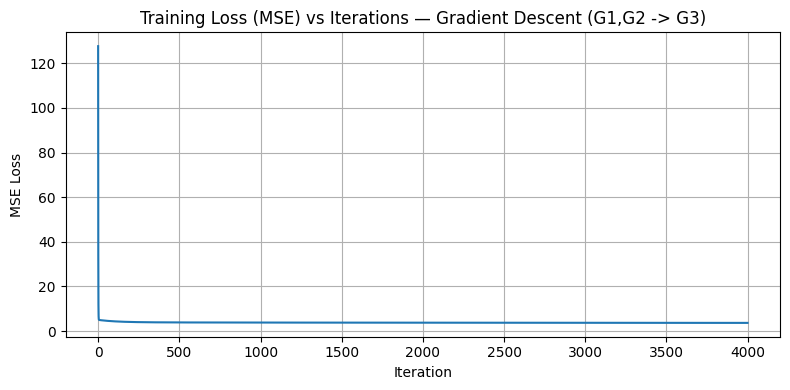

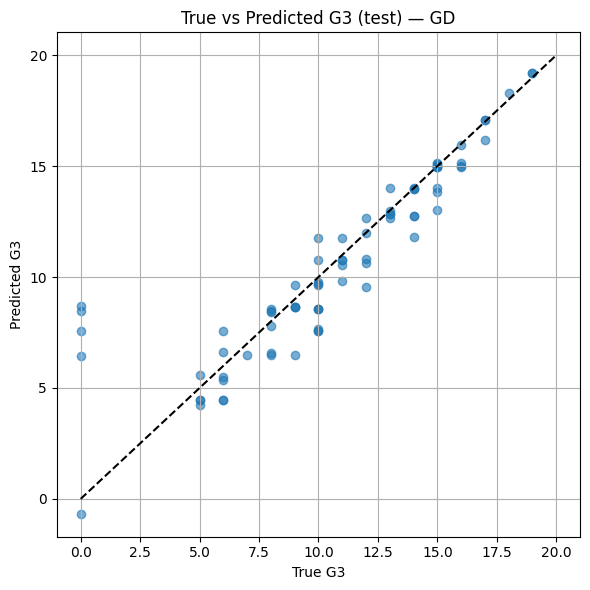


Other-feature matrix shape after encoding: (395, 39)
Iter 0, loss=127.629747
Iter 800, loss=17.120407
Iter 1600, loss=16.317606
Iter 2400, loss=15.978817
Iter 3200, loss=15.788517

--- Bonus results (excluding G1,G2) ---
Closed-form RMSE train: 3.8651, test: 4.1957
GD RMSE train: 3.9581, test: 4.2680


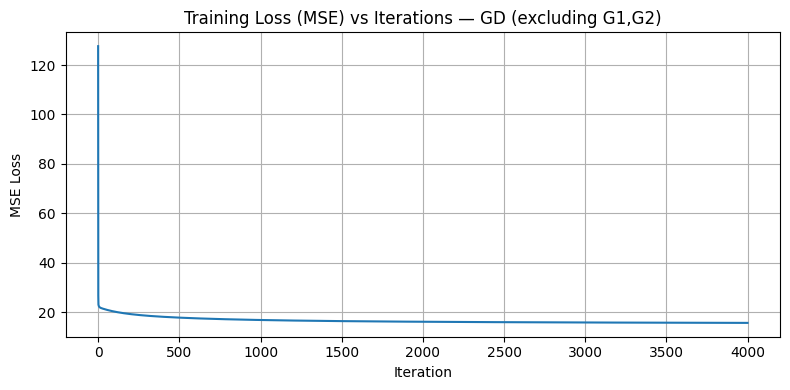


Saved plots: loss_g1g2.png, true_vs_pred_g1g2.png, loss_excluding_g1g2.png
Saved test predictions sample: predictions_g1g2_test_sample.csv


In [4]:
# Linear regression from scratch — Student Performance (UCI)
# Usage:
#  - Place student-mat.csv or student-por.csv in same folder and set DATA_FILE variable below.
#  - Run in Jupyter or python environment with numpy, pandas, matplotlib, sklearn (for split convenience).
#
# This implements:
#  - EDA summary
#  - Linear regression (closed-form normal equation with tiny ridge reg)
#  - Gradient descent (batch) from scratch with MSE loss + training loss plot
#  - RMSE on train and test
#  - Bonus: run model excluding G1,G2 (use other features)
#  - Saves plots to png files

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import os

# ---------- User config ----------
DATA_FILE = 'student-mat.csv'   # change to 'student-por.csv' if desired
SEP = ';'                      # UCI student files use semicolon
RANDOM_STATE = 42
TEST_SIZE = 0.2
# Gradient descent hyperparameters
LR = 0.001
N_ITERS = 4000
# ---------------------------------

# ---------- Utility functions ----------
def add_bias(X):
    return np.hstack([np.ones((X.shape[0],1)), X])

def predict(X, w):
    return X.dot(w)

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))

def closed_form_solution(X, y, reg=1e-8):
    XtX = X.T.dot(X)
    w = np.linalg.inv(XtX + reg*np.eye(XtX.shape[0])).dot(X.T).dot(y)
    return w

def gradient_descent(X, y, lr=1e-3, n_iters=1000, verbose=False):
    n, d = X.shape
    w = np.zeros(d)
    losses = []
    for it in range(n_iters):
        y_pred = X.dot(w)
        loss = mse(y, y_pred)
        losses.append(loss)
        grad = (-2/n) * X.T.dot(y - y_pred)
        w = w - lr * grad
        if verbose and (it % max(1, n_iters//5) == 0):
            print(f"Iter {it}, loss={loss:.6f}")
    return w, np.array(losses)

# ---------- Load dataset ----------
if not os.path.exists(DATA_FILE):
    raise FileNotFoundError(f"{DATA_FILE} not found. Download student-mat.csv or student-por.csv from UCI and place here.")

df = pd.read_csv(DATA_FILE, sep=SEP)
print("Loaded dataset shape:", df.shape)
print("Columns:", list(df.columns))

# ---------- EDA (brief) ----------
print("\n=== Brief EDA ===")
print(df.describe(include='all').T[['count','mean','std','min','25%','50%','75%','max']].head(20))
print("\nValue counts for categorical columns (sample):")
for col in df.select_dtypes(include=['object']).columns:
    print(f"\n{col} value counts:")
    print(df[col].value_counts(dropna=False).to_dict())

# ---------- Subtask A: Predict G3 using G1, G2 only ----------
X = df[['G1','G2']].values.astype(float)
y = df['G3'].values.astype(float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

X_train_b = add_bias(X_train)
X_test_b = add_bias(X_test)

# Closed-form
w_cf = closed_form_solution(X_train_b, y_train, reg=1e-8)
y_train_pred_cf = predict(X_train_b, w_cf)
y_test_pred_cf = predict(X_test_b, w_cf)
train_rmse_cf = rmse(y_train, y_train_pred_cf)
test_rmse_cf = rmse(y_test, y_test_pred_cf)

# Gradient descent
w_gd, losses = gradient_descent(X_train_b, y_train, lr=LR, n_iters=N_ITERS, verbose=True)
y_train_pred_gd = predict(X_train_b, w_gd)
y_test_pred_gd = predict(X_test_b, w_gd)
train_rmse_gd = rmse(y_train, y_train_pred_gd)
test_rmse_gd = rmse(y_test, y_test_pred_gd)

print("\n--- Subtask A results (G1,G2 -> G3) ---")
print("Closed-form weights:", w_cf)
print(f"Closed-form RMSE train: {train_rmse_cf:.4f}, test: {test_rmse_cf:.4f}")
print("GD weights:", w_gd)
print(f"GD RMSE train: {train_rmse_gd:.4f}, test: {test_rmse_gd:.4f}")

# Plot training loss vs iterations
plt.figure(figsize=(8,4))
plt.plot(np.arange(len(losses)), losses)
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.title("Training Loss (MSE) vs Iterations — Gradient Descent (G1,G2 -> G3)")
plt.grid(True)
plt.tight_layout()
plt.savefig("loss_g1g2.png", dpi=150)
plt.show()

# Optional: scatter true vs predicted on test
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred_gd, alpha=0.6)
plt.plot([0,20],[0,20],'k--')
plt.xlabel("True G3")
plt.ylabel("Predicted G3")
plt.title("True vs Predicted G3 (test) — GD")
plt.grid(True)
plt.tight_layout()
plt.savefig("true_vs_pred_g1g2.png", dpi=150)
plt.show()

# ---------- Bonus: Exclude G1,G2 (use other features) ----------
# Prepare other features: encode categorical variables (one-hot) and scale numeric a bit
df_other = df.copy()
# Drop G1,G2,G3 from features
y2 = df_other['G3'].values.astype(float)
X_other = df_other.drop(columns=['G1','G2','G3'])

# One-hot encode categorical features (pandas.get_dummies)
X_other_enc = pd.get_dummies(X_other, drop_first=True).astype(float)
print("\nOther-feature matrix shape after encoding:", X_other_enc.shape)

X2 = X_other_enc.values
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=TEST_SIZE, random_state=RANDOM_STATE)

# Add bias
X2_train_b = add_bias(X2_train)
X2_test_b = add_bias(X2_test)

# Closed-form
w2_cf = closed_form_solution(X2_train_b, y2_train, reg=1e-6)  # slightly larger reg to help invertibility
y2_train_pred_cf = predict(X2_train_b, w2_cf)
y2_test_pred_cf = predict(X2_test_b, w2_cf)
train2_rmse_cf = rmse(y2_train, y2_train_pred_cf)
test2_rmse_cf = rmse(y2_test, y2_test_pred_cf)

# Gradient descent
w2_gd, losses2 = gradient_descent(X2_train_b, y2_train, lr=LR, n_iters=N_ITERS, verbose=True)
y2_train_pred_gd = predict(X2_train_b, w2_gd)
y2_test_pred_gd = predict(X2_test_b, w2_gd)
train2_rmse_gd = rmse(y2_train, y2_train_pred_gd)
test2_rmse_gd = rmse(y2_test, y2_test_pred_gd)

print("\n--- Bonus results (excluding G1,G2) ---")
print(f"Closed-form RMSE train: {train2_rmse_cf:.4f}, test: {test2_rmse_cf:.4f}")
print(f"GD RMSE train: {train2_rmse_gd:.4f}, test: {test2_rmse_gd:.4f}")

# Plot loss for bonus
plt.figure(figsize=(8,4))
plt.plot(np.arange(len(losses2)), losses2)
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.title("Training Loss (MSE) vs Iterations — GD (excluding G1,G2)")
plt.grid(True)
plt.tight_layout()
plt.savefig("loss_excluding_g1g2.png", dpi=150)
plt.show()

# Save brief CSV with predictions for inspection
out = pd.DataFrame({
    'true_G3_test': y_test,
    'pred_gd_g1g2': y_test_pred_gd,
    'pred_cf_g1g2': y_test_pred_cf
})
out.to_csv("predictions_g1g2_test_sample.csv", index=False)

print("\nSaved plots: loss_g1g2.png, true_vs_pred_g1g2.png, loss_excluding_g1g2.png")
print("Saved test predictions sample: predictions_g1g2_test_sample.csv")
